In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pathlib import Path

BASE    = Path(r"C:\Users\pacor\Documents\Notebooks\Python\Inpat Expat\inpat-expat\corto-muso")
DB_PATH = BASE / "tm_football.db"
DATA    = BASE / "data"


In [24]:
def corto_muso_summary(managers, data):
    wins = data[data["result"] == "W"].copy()

    wins["is_one_nil"] = (
        (wins["goals_for"] == 1) & (wins["goals_against"] == 0)
    )
    wins["is_min_response"] = (
        (wins["goals_against"] > 0) & (wins["goal_diff"] == 1)
    )

    assert (wins["is_one_nil"] & wins["is_min_response"]).sum() == 0, "overlap detected"

    wins["is_corto_muso_win"] = wins["is_one_nil"] | wins["is_min_response"]

    summary = (
        wins[wins["manager"].isin(managers)]
        .groupby("manager")
        .agg(
            total_wins   = ("result", "count"),
            one_nil      = ("is_one_nil", "sum"),
            min_response = ("is_min_response", "sum"),
            corto_muso   = ("is_corto_muso_win", "sum"),
        )
        .loc[managers]
    )
    summary["1-0_%"]        = (summary["one_nil"]      / summary["total_wins"] * 100).round(1)
    summary["min_resp_%"]   = (summary["min_response"] / summary["total_wins"] * 100).round(1)
    summary["corto_muso_%"] = (summary["corto_muso"]   / summary["total_wins"] * 100).round(1)

    return summary

In [26]:
def get_counts(manager_name, data):
    sub   = data[data["manager"] == manager_name]
    w     = sub[sub["result"] == "W"].copy()
    w["is_one_nil"]      = (w["goals_for"] == 1) & (w["goals_against"] == 0)
    w["is_min_response"] = (w["goals_against"] > 0) & (w["goal_diff"] == 1)
    w_opp = w[w["goals_against"] > 0]
    return {
        "matches"    : len(sub),
        "wins"       : len(w),
        "one_nil"    : int(w["is_one_nil"].sum()),
        "min_resp"   : int(w["is_min_response"].sum()),
        "opp_scored" : len(w_opp),
    }


> [*Non c'e' bisogno che vinci di 100, basta mettere il muso d'avanti*](https://www.youtube.com/watch?v=xbcC8oXZzvA) - Massimiliano Allegri sul corto muso

Spesso ho l'impressione che chi segua il calcio, anche tra gli addetti ai lavori, abbia un atteggiamento schizofrenico nei confronti dei numeri e della matematica. Il calcio e' un gioco che, nel momento in cui si trasforma in sport, definisce delle misure e quindi, intrinsecamente, dei parametri per confrontare queste misure. Si puo' benissimo *giocare* a calcio, come fanno i bambini, e il tuo scopo e' divertirti calciando una palla e cercando di controllarla e direzionarla mentre rimbalza. Personalmente, e' come se ci fosse una gioia interiore nel solo cercare di padroneggiare la palla, scartare i tuoi avversari, correre e, al tempo stesso, direzionare un oggetto che, d'avanti a te, rimbalza e si sposta in maniera spesso imprevedibile. Tutto questo, immaginandoti nello stadio Azteca di Citta' del Messico. E questo e' il gioco. Lo sport inizia, ad esempio, quando iniziamo a contare i goal che facciamo o che subiamo e, quindi, a misurare una prestazione. Da li in poi, si possono definire altre misure e quindi numeri che le rappresentano. 

Ci piaccia o no, e [capisco che non possa piacere](https://www.tuttonapoli.net/radio-tutto-napoli/conte-batte-quasi-sempre-allegri-cagni-ma-statistiche-non-dicono-nulla-641402), ma una volta che si mettono in mezzo i numeri e le misure, e' difficile non farci entrare concetti come la probabilita' e la statistica. Parlando di calcio, non e' obbligatorio parlare di numeri e statistica. Si possono descrivere le partite anche in termini coinvolgimento emotivo, usando parametri soggettivi come la bellezza, l'ansia, la felicita' e il terrore. 

Se si vuole, pero', parlare di calcio attraverso i numeri, e quindi usando misure, e' bene essere chiari e onesti so come trattarli e comunicarli. Inoltre, se si vogliono usare i numeri per dimostrare una tesi, allora bisogna dichiarare a che gioco si vuol giocare dal principio per evitare fraintendimenti. Un "approccio scientifico" all'interpretazione dei risultati nel calcio e' possibile, secondo me, se si sa di cosa si parla e si comunicano chiaramente gli obiettivi e i limiti. Nessuno ci obbliga a farlo, ma se lo facciamo cerchiamo di farlo con cognizione di causa e chiarendo subito cosa si vuol ottenere. Evitare equivoci ci permetterebbe anche di avere una discussione onesta ed evitare di parlare di "fatti inequivocabili e dimostrabili" quando questi non ci sono. 

In questo articolo, cerchero' di spiegare come fare una semplice analisi statistica sul "corto muso", cercando di capire se, attraverso l'analisi dei risultati ottenuti da diversi allenatori, esistano differenze "statisticamente significativa" tra i risulitati ottenuti. Ci tengo subito a precisare che l'analisi statistica che verra' parte e tratta solo i risultati ottenuti. Non parlo di come impostare il gioco o delle tattiche usate per ottenere i risultati, ma solo di quello che vediamo alla fine della partita: il risultato. La vittoria, il pareggio, la sconfitta, i goal fatti e quelli subiti. Nulla che riguardi il possesso palla, le azioni create, i passaggi o la costruzione del gioco: non "il come" si e' ottenuto un risultato, ma il risultato stesso. Parto da ambizioni basse, me ne rendo conto, ma forse possono servire a spiegare alcuni degli strumenti che possono essere usati per fare analisi piu' sofisticate. Quello che mi interessa, e' spiegare alcuni tra i concetti e le idee che sottendono le analisi statistiche che ci permettono di trarre conclusioni basate sui numeri. 

## Una definizione del corto muso. Non l'unica, ma almeno una. 

Pare che partire dalla *definizione del problema che vogliamo discutere* sia una delle migliori pratiche da seguire nell'approccio scientifico. E chi sono io per discutere questa massima di saggezza popolare? Quello che vogliamo, e' formulare una definizione di corto muso che sia misurabile attraverso dei dati a disposizione. Il concetto di "corto muso" definito da Allegri e' intuitivamente semplice, ma se vogliamo farne un'indagine statistica dobbiamo capire quali dati a disposizione abbiamo per poterla studiare con un approccio scientifico. In fisica, quando si vuole studiare un fenomeno, si cerca di partire sempre dal modello piu' semplice possibile. E' famosa (tra i fisici, non tra le persone normali che hanno altro da fare) la battuta di un professore di fisica che inizia una discussione con "assumiamo che una mucca sia una sfera". Ovvio che una mucca non e' una sfera, ma in alcuni casi modellarla come una sfera puo' aiutarti a capire alcuni suoi comportamenti. 

- percentuale di vittorie
- percentuale di vittorie per 1-0
- percentuale di vittorie ottenute con un solo goal di scarto

Il confronto verra' fatto con i seguenti allenatori:

- Pep Guardiola
- José Mourinho
- Antonio Conte
- Carlo Ancelotti
- Roberto De Zerbi
- Vincenzo Italiano
- Simone Inzaghi
- Maurizio Sarri
- Jürgen Klopp
- Unai Emery
- Diego Simeone

Verranno considerate tutte le partite allenate dagli allenatori a partire dalla stagione 2008-2009.

In [3]:
mm_all = pd.read_csv(DATA / "processed/manager_matches.csv", parse_dates=["date"])

MANAGERS = [
    "Massimiliano Allegri",
    "Pep Guardiola",
    "José Mourinho",
    "Antonio Conte",
    "Carlo Ancelotti",
    "Simone Inzaghi",
    "Maurizio Sarri",
    "Jürgen Klopp",
    "Unai Emery",
    "Diego Simeone",
]

PEERS = [m for m in MANAGERS if m != "Massimiliano Allegri"]

mm = mm_all[mm_all["manager"].isin(MANAGERS)].copy()

print(f"Rows: {len(mm):,}  |  Managers: {len(MANAGERS)}")
print(mm["manager"].value_counts().to_string())


Rows: 4,970  |  Managers: 10
manager
Pep Guardiola           633
Unai Emery              605
Diego Simeone           572
Massimiliano Allegri    544
Carlo Ancelotti         531
José Mourinho           523
Jürgen Klopp            450
Antonio Conte           393
Maurizio Sarri          370
Simone Inzaghi          349


Un paio di note a margine per precisare meglio i dati che useremo per l'analisi. Considereremo
- Partite dalla stagione 2008/09 in poi
- Partite giocate nei 5 campionati Europei principali: Inghilterra, Spagna, Germania, Italia e Francia - niente Portogallo o Arabia Saudita
- Partite di campionato e non di coppa o nazionali (Conte, Ancelotti)
- Le partite nelle quali gli allenatori erano squalificati non compaiono nell'analisi (l'ho fatto per fondamentalmente per pigrizia. Nella raccolta dei dati delle partite, ho filtrato per allenatore in panchina per la partita. Se l'allenatore non era presente in quella partita, con compare nell'analisi. Stiamo parlando di una percentuale minima che non influenza l'analisi statistica. Ah, Conte squalificato per scommesse. *Agghiaggiante!!*)

Come si vede dalla tabella, stiamo considerando una media di 500 partite per allenatore, da un massimo di 633 per Guardiola alle 349 di Simone Inzaghi. Ovviamente quando si andranno a fare i test statistici, questi terranno conto anche della differenza tra il numero di partite giocate per ogni allenatore e questo influenza il risultato.

Text(0.5, 1.0, 'Partite per Allenatore - 2008-2026')

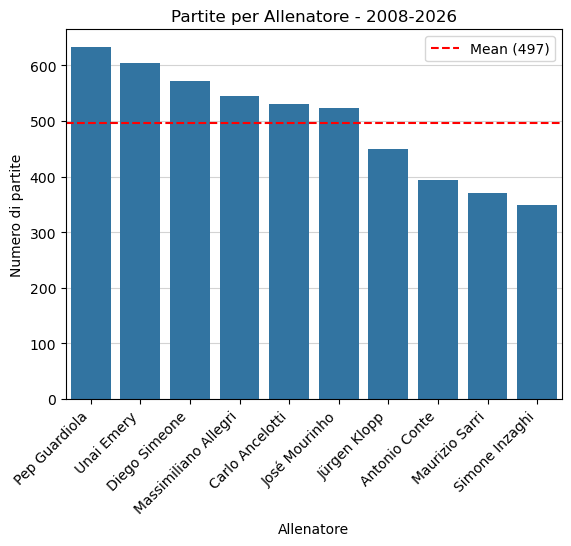

In [7]:
ax = sns.barplot(mm["manager"].value_counts())

plt.xticks(rotation=45, ha="right")

ax.yaxis.grid(True, color="lightgrey", linestyle="-", linewidth=0.8)
ax.set_axisbelow(True)

mean_val = mm["manager"].value_counts().mean()
ax.axhline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean ({mean_val:.0f})")

ax.legend()

ax.set_xlabel("Allenatore")
ax.set_ylabel("Numero di partite")
ax.set_title("Partite per Allenatore - 2008-2026")



### Partite e Percentuali

A questo punto, per ogni allenatore calcoliamo quante partite sono state vinte, quante per 1-0 e quante sono state vinte con un goal di scarto.

In [8]:


def baseline(df):
    wins  = df[df["result"] == "W"]
    total = len(df)
    tw    = len(wins)
    one_nil    = ((wins["goals_for"] == 1) & (wins["goals_against"] == 0)).sum()
    plus1_all  = (wins["goal_diff"] == 1).sum()
    plus1_excl = ((wins["goal_diff"] == 1) & (wins["goals_against"] > 0)).sum()
    blowout    = (wins["goal_diff"] >= 3).sum()
    return pd.Series({
        "matches"        : total,
        "win_%"          : round(tw / total * 100, 1),
        "1-0_%_wins"     : round(one_nil   / tw * 100, 1) if tw else None,
        "+1_%_wins"      : round(plus1_all  / tw * 100, 1) if tw else None,
        "+1_excl1-0_%"   : round(plus1_excl / tw * 100, 1) if tw else None,
        "blowout_%_wins" : round(blowout    / tw * 100, 1) if tw else None,
        "avg_ga"         : round(df["goals_against"].mean(), 2),
    })

# ref = mm.groupby("manager").apply(baseline).loc[MANAGERS]
# print(ref.sort_values("1-0_%_wins", ascending = False).to_string())

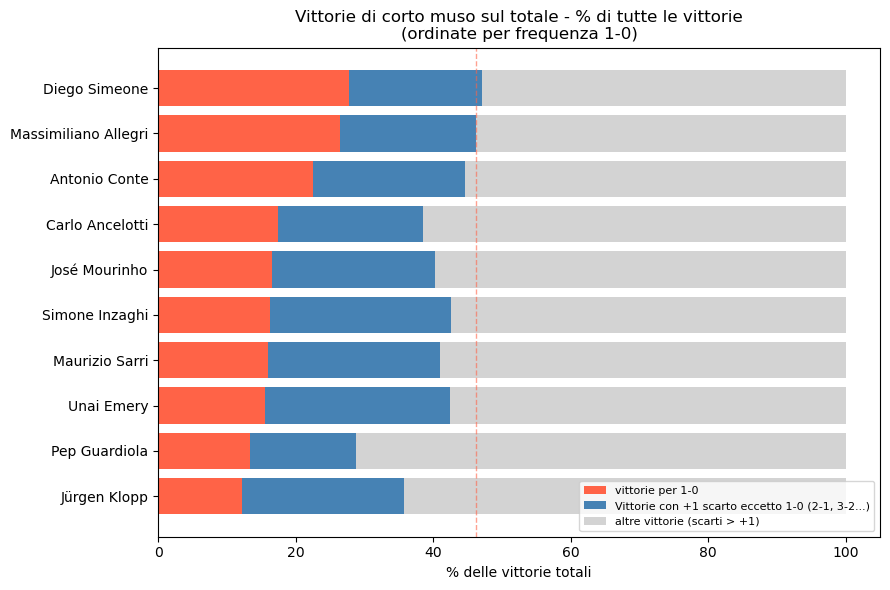

                      matches  win_%  1-0_%_wins  +1_%_wins  +1_excl1-0_%  blowout_%_wins  avg_ga
manager                                                                                          
Diego Simeone           572.0   59.8        27.8       47.1          19.3            22.8    0.83
Massimiliano Allegri    544.0   59.2        26.4       46.3          19.9            22.0    0.89
Antonio Conte           393.0   65.4        22.6       44.7          22.2            24.1    0.87
Carlo Ancelotti         531.0   64.0        17.4       38.5          21.2            35.3    0.92
José Mourinho           523.0   58.9        16.6       40.3          23.7            29.2    0.97
Simone Inzaghi          349.0   59.9        16.3       42.6          26.3            29.2    1.10
Maurizio Sarri          370.0   54.1        16.0       41.0          25.0            24.5    1.06
Unai Emery              605.0   51.9        15.6       42.4          26.8            25.5    1.17
Pep Guardiola       

In [9]:
# stacked horizontal bar: 1-0 wins, +1 excl 1-0, other wins — % of total wins
ref2 = mm.groupby("manager").apply(baseline).loc[MANAGERS].copy()

# sort by 1-0% descending
ref2 = ref2.sort_values("1-0_%_wins", ascending=True)  # ascending=True: top of chart = highest

other = 100 - ref2["+1_%_wins"] - ref2["blowout_%_wins"]
# "other wins" = wins that are not +1 GD and not blowouts
other_pct = 100 - ref2["+1_%_wins"] - ref2["blowout_%_wins"]

fig, ax = plt.subplots(figsize=(9, 6))

bars1 = ax.barh(ref2.index, ref2["1-0_%_wins"],
                color="tomato", label="vittorie per 1-0")
bars2 = ax.barh(ref2.index, ref2["+1_excl1-0_%"],
                left=ref2["1-0_%_wins"],
                color="steelblue", label="Vittorie con +1 scarto eccetto 1-0 (2-1, 3-2...)")
bars3 = ax.barh(ref2.index, 100 - ref2["+1_%_wins"],
                left=ref2["+1_%_wins"],
                color="lightgrey", label="altre vittorie (scarti > +1)")

ax.axvline(ref2.loc["Massimiliano Allegri", "+1_%_wins"],
           color="tomato", linestyle="--", linewidth=1, alpha=0.6)

ax.set_xlabel("% delle vittorie totali")
ax.set_title("Vittorie di corto muso sul totale - % di tutte le vittorie\n(ordinate per frequenza 1-0)")
ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

ref = mm.groupby("manager").apply(baseline).loc[MANAGERS]
print(ref.sort_values("1-0_%_wins", ascending = False).to_string())

Consideriamo singolarmente tre parametri: le percentuali di vittorie, le vittorie per 1-0, e le vittorie con un solo goal di scarto. 

In [10]:
# ref[['matches', 'win_%']].sort_values('win_%', ascending=False).reset_index()

ref_sorted = ref[['matches', 'win_%']].sort_values('win_%', ascending=False).reset_index()
allegri_win = ref_sorted.loc[ref_sorted['manager'] == 'Massimiliano Allegri', 'win_%'].values[0]
ref_sorted['win_%_diff_allegri'] = (ref_sorted['win_%'] - allegri_win).round(1)
print(ref_sorted)

                manager  matches  win_%  win_%_diff_allegri
0         Pep Guardiola    633.0   73.6                14.4
1         Antonio Conte    393.0   65.4                 6.2
2       Carlo Ancelotti    531.0   64.0                 4.8
3          Jürgen Klopp    450.0   60.2                 1.0
4        Simone Inzaghi    349.0   59.9                 0.7
5         Diego Simeone    572.0   59.8                 0.6
6  Massimiliano Allegri    544.0   59.2                 0.0
7         José Mourinho    523.0   58.9                -0.3
8        Maurizio Sarri    370.0   54.1                -5.1
9            Unai Emery    605.0   51.9                -7.3


In [11]:
ref['1-0_%_wins'] + ref['+1_excl1-0_%'] == ref['+1_%_wins']

manager
Massimiliano Allegri     True
Pep Guardiola            True
José Mourinho            True
Antonio Conte           False
Carlo Ancelotti         False
Simone Inzaghi           True
Maurizio Sarri           True
Jürgen Klopp             True
Unai Emery               True
Diego Simeone            True
dtype: bool

---

## Il segnale e il rumore

Nei paragrafi precedenti abbiamo contato, per ogni allenatore, le partite vinte per 1-0 e calcolato la percentuale sul totale delle vittorie. Questa percentuale prova a tradurre numericamente uno degli assiomi del corto muso: cercare di vincere, quando si vince, con il minimo sforzo.

In [12]:
ref_10 = ref[['matches', '1-0_%_wins']].sort_values('1-0_%_wins', ascending=False).reset_index()
allegri_10 = ref_10.loc[ref_10['manager'] == 'Massimiliano Allegri', '1-0_%_wins'].values[0]
ref_10['1-0_%_diff_allegri'] = (ref_10['1-0_%_wins'] - allegri_10).round(1)
print(ref_10)

                manager  matches  1-0_%_wins  1-0_%_diff_allegri
0         Diego Simeone    572.0        27.8                 1.4
1  Massimiliano Allegri    544.0        26.4                 0.0
2         Antonio Conte    393.0        22.6                -3.8
3       Carlo Ancelotti    531.0        17.4                -9.0
4         José Mourinho    523.0        16.6                -9.8
5        Simone Inzaghi    349.0        16.3               -10.1
6        Maurizio Sarri    370.0        16.0               -10.4
7            Unai Emery    605.0        15.6               -10.8
8         Pep Guardiola    633.0        13.3               -13.1
9          Jürgen Klopp    450.0        12.2               -14.2


Dalla tabella, sembrerebbe che Allegri abbia una tendenza a vincere per 1-0 superiore alla maggior parte dei suoi colleghi, fatta eccezione per Diego Simeone. Le differenze sono di varia entità: circa quattro punti percentuali rispetto ad Antonio Conte, tredici rispetto a Guardiola, quattordici rispetto a Klopp.

Sono numeri diversi. Ma sono differenze *statisticamente* diverse? La domanda non è oziosa, e per rispondere bisogna capire cosa stiamo davvero misurando quando calcoliamo questa percentuale.

### Una percentuale è una stima, non una verità

Quando diciamo che il 26.4% delle vittorie di Allegri è arrivato per 1-0, stiamo facendo una misura su un campione finito di partite, ossia le 322 vittorie che Allegri ha effettivamente collezionato nei dati che abbiamo. Quella percentuale e' la nostra migliore *stima* della sua tendenza a vincere 1-0, ma non è la tendenza stessa. È il numero che esce dalla nostra misurazione, con tutta la variabilità che una misurazione si porta dietro.

Questa distinzione non e' una sottigliezza filosofica, ma e' esattamente il punto pratico. Se Allegri allenasse altre 322 partite con lo stesso atteggiamento, la percentuale di 1-0 non sarebbe esattamente 26.4%. Sarebbe vicina, ma non identica. Potrebbe essere 25%, potrebbe essere 28%. C'è una "probabilita' vera" sottostante, ossia quella che riflette davvero come Allegri imposta le partite, e c'e' la "percentuale osservata", che è quello che vediamo nei dati. Le due coincidono solo nel limite di un numero infinito di partite, che non abbiamo a disposizione.

Per capire quanto possa essere ampia questa variabilità, l'esempio classico è quello del lancio della moneta.

### L'esempio della moneta

Supponiamo di avere una moneta non truccata: la probabilità "vera" che esca testa e' del 50%. Se vi trovate a una festa con molti invitati laureati in fisica o in matematica, potete dire che questo  e' il valore di massima entropia per una variabile binaria che è la stessa cosa che diremmo intuitivamente: non c'è motivo di preferire un esito all'altro. A proposito di probabilita', "feste" con molti invitati "fisici" e' un evento improbabile. "Feste" con "fisici" e "divertenti", li credo abbiamo bisogno di definire metriche nuove per misurare gli infinitesimi.

Usiamo una funzione Python, `np.random.binomial`, che simula il numero di teste ottenute in $N$ lanci. Lanciamo dieci monete, una volta sola:

In [13]:
np.random.seed(42)
np.random.binomial(n=10, p=0.5, size=1)

array([4], dtype=int32)

Il risultato e' `[4]`: su dieci lanci sono uscite quattro teste. Non cinque, come ci si potrebbe aspettare. Nessuno chiamerebbe truccata la moneta per questo. Ripetiamo l'esperimento cinque volte, sempre con dieci lanci ciascuno:

In [14]:
np.random.seed(42)
np.random.binomial(n=10, p=0.5, size=5)

array([4, 8, 6, 5, 3], dtype=int32)

Risultati: 4, 8, 6, 5, 3 teste — ossia $40\%$, $80\%$, $60\%$, $50\%$, $30\%$. La moneta è la stessa, la probabilità "vera" è sempre del $50\%$, ma la percentuale *osservata* in ciascun esperimento oscilla parecchio. Con dieci lanci, la variabilità e' grande.

Il nostro intuito ci dice anche che, aumentando il numero di lanci, le stime dovrebbero stringersi attorno al valore vero. Verifichiamo: cinque esperimenti, ma stavolta con 100 lanci ciascuno.

In [15]:
np.random.seed(42)
np.random.binomial(n=100, p=0.5, size=5)

array([49, 52, 44, 42, 58], dtype=int32)

Risultati: 49, 52, 44, 42, 58 teste, ossia percentuali tra il $42\%$ e il $58\%$. L'oscillazione c'è ancora, nemmeno un $50\%$ spaccato, ma e' molto più contenuta che con dieci lanci. E' la lezione fondamentale: **la variabilità di una percentuale dipende dalla dimensione del campione su cui la misuriamo.** Più dati, meno rumore.

E qui torniamo al calcio.

### Cosa fa un test statistico

Il test di proporzione si pone esattamente questa domanda, ma in una forma rovesciata che vale la pena spiegare. Il test parte da un'ipotesi di partenza, detta *ipotesi nulla*: supponiamo che Allegri e Klopp abbiano in realtà la *stessa* probabilità di vincere 1-0. Chiamiamo questa probabilita' $p$, qualunque essa sia. Anche se puo' sembrare fatto a posta, spesso si usano simboli simili per rappresentare cose diverse: la probabilita' $p$ non ha nulla a che fare con il *p-value* che definiremo poi. Anzi, ammettiamolo: lo facciamo apposta per confondervi. E confonderci. Sotto questa ipotesi, le differenze che osserviamo tra le percentuali misurate dovrebbero essere solo rumore di misurazione, come nell'esperimento delle monete.

A questo punto il test calcola: dato il rumore atteso (che dipende dalle dimensioni dei due campioni, 322 e 271), quanto è probabile osservare una differenza *grande almeno quanto quella che abbiamo visto*, ossia quattordici punti percentuali, se davvero le due probabilità sottostanti fossero uguali?

***Questa probabilità si chiama p-value***. È un numero importante e spesso frainteso. Il p-value **non è** la probabilità che le due percentuali siano uguali. Non è la probabilità che l'ipotesi nulla sia vera. E', più precisamente, la probabilità di osservare una differenza grande come quella che vediamo, o ancora più grande, *assumendo che* le due probabilità sottostanti siano davvero identiche.

Se il p-value è basso, vuol dire: una differenza di questa entità sarebbe molto sorprendente se le due probabilità fossero uguali. Quindi *forse* non lo sono. Se il p-value è alto, vuol dire: una differenza di questa entità è perfettamente compatibile con due probabilità uguali e un po' di rumore e quindi non abbiamo motivo di affermare che siano diverse.

Notare il "non abbiamo motivo di affermare che siano diverse" è molto diverso da "abbiamo dimostrato che sono uguali". I test statistici, in generale, non *dimostrano* niente. Ci dicono quanto sia compatibile quello che vediamo con un'ipotesi di partenza. La conclusione finale, su cosa significa quella compatibilità, sta a noi.

### Un esempio ai due estremi: Allegri vs Klopp

Credo sia difficile trovare due commentatori che trovino l'approccio alle gare di Allegri e Klopp (in rigoroso ordine alfabetico) simile. Questa frase sarebbe piaciuta a statisti quali Romano Prodi, famoso per le sue dichiarazioni dirompenti e provocatorie. Inutile sottolineare le differenze nello stile in cui questi allenatori affrontano le partite e sta al gusto di chi le guarda e commenta decidere quale approccio preferire (spirito di Romano Prodi, esci da questo corpo!!). Ma questo approccio diverso, si riflette poi sui risultati? 

Precisazione importante: Allegri e Klopp hanno allenato in campionati diversi e questo influenza l'*interpretazione* del test statistico. Il test di proporzione non sa cosa sia un campionato. Confronta due numeri e si chiede se la differenza che osserviamo sta dentro al normale rumore statistico. E questo e'. Ma la Serie A e' tradizionalmente un campionato che produce meno goal della Premier League: un allenatore di Serie A vedra' piu' 1-0 semplicemente per il contesto in cui lavora, non per una sua specifica caratteristica filosofica. Quindi anche se il test trovasse una differenza significativa tra Allegri e Klopp, attribuirla all'allenatore richiede un salto interpretativo che il test, per quanto ben fatto, non e' in grado di giustificare da solo. E qui c'e' una distinzione che vale la pena tenere a mente per tutta l'analisi che segue: **il risultato di un test statistico e' una cosa, la sua interpretazione e' un'altra**. Che non significa che si possa fare cherry picking o che il test sia inutile perche' tanto lo si interpreta come si vuole: significa porre dei paletti importanti che indirizzano e vincolano l'interpretazione. Insomma, una volta fatto il test, non si puo' dire tutto e il contrario di tutto.

Andiamo a vedere i numeri che hanno i due allenatori per quanto riguarda numero di vittorie, numero di vittorie per 1-0 e numero di vittorie con un solo goal di scarto.

In [29]:
managers = ["Massimiliano Allegri", "Jürgen Klopp"]

summary = corto_muso_summary(managers, mm)
print(summary.to_string())



                      total_wins  one_nil  min_response  corto_muso  1-0_%  min_resp_%  corto_muso_%
manager                                                                                             
Massimiliano Allegri         322       85            64         149   26.4        19.9          46.3
Jürgen Klopp                 271       33            64          97   12.2        23.6          35.8


Come numero di vittorie, il numero e' comparabile (e anche la percentuale di vittorie per partite giocate e' simile, come riportato in una delle tabelle iniziali). Chiariamo che, in questa tabella, le vittorie di risposta minima (`min_resp`), sono quelle in cui l'avversario ha segnato almeno un goal, e la vittorie e' avvenuta con un goal di scarto. Se ci concentriamo sulle percentuali, abbiamo tre casi: la percentuale di vittorie per 1-0 di Allegri e' superiore a quella di Klopp di circa 14 punti percentuali (sembra riportare i risultati di un'elezione in Basilicata); la percentuale di vittorie con un solo goal di scarto (escludendo gli 1-0) di Klopp e' superiore a quella di Allegri di poco meno di 4 punti; infine la percentuale di vittorie di corto muso (la somma delle due) e' ancora a favore di Allegri di poco meno di 11 punti.

Ci chiediamo: queste differenze, sono statisticamente significative? Riflettono un effetto reale dell'allenatore e del suo approccio, oppure sono semplicemente quello che ci aspettiamo dal caso e dalla normale variabilità delle misure?

In [31]:
322-271

51

In [ ]:
# # B.1 — two-proportion z-test: Allegri vs each peer, three parameters
# def get_counts(manager_name):
#     sub   = mm[mm["manager"] == manager_name]
#     w     = wins[wins["manager"] == manager_name]
#     w_opp = w[w["goals_against"] > 0]
#     return {
#         "matches"    : len(sub),
#         "wins"       : len(w),
#         "one_nil"    : int(w["is_one_nil"].sum()),
#         "min_resp"   : int(w["is_min_response"].sum()),
#         "opp_scored" : len(w_opp),
#     }

# allegri = get_counts("Massimiliano Allegri", mm)
# klopp = get_counts("Jürgen Klopp", mm)

# print(allegri)
# print(klopp)

{'matches': 544, 'wins': 322, 'one_nil': 85, 'min_resp': 64, 'opp_scored': 110}
{'matches': 450, 'wins': 271, 'one_nil': 33, 'min_resp': 64, 'opp_scored': 131}


In [23]:
from statsmodels.stats.proportion import proportion_confint, proportions_ztest


p_win_allegri = allegri["wins"] / allegri["matches"]
p_win_klopp   = klopp["wins"] / klopp["matches"]

p_win_10_allegri = allegri["one_nil"] / allegri["wins"]
p_win_10_klopp   = klopp["one_nil"] / klopp["wins"]

z1, pv1 = proportions_ztest([allegri["wins"], klopp["wins"]],
                            [allegri["matches"], klopp["matches"]])

z2, pv2 = proportions_ztest([allegri["one_nil"], klopp["one_nil"]],
                            [allegri["wins"], klopp["wins"]])

print("Probabilita' di vittoria per Allegri = {}, Probabilita' di vittoria per Klopp = {}".format(round(p_win_allegri * 100, 1), round(p_win_klopp * 100, 1))   )
print("Z-test statistic: {:.3f}, p-value: {:.3f}".format(z1, pv1))

print("Probabilita' di vincere 1-0 per Allegri = {}, Probabilita' di vittoria per Klopp = {}".format(round(p_win_10_allegri * 100, 1), round(p_win_10_klopp * 100, 1))   )
print("Z-test statistic: {:.3f}, p-value: {:.3f}".format(z2, pv2))


Probabilita' di vittoria per Allegri = 59.2, Probabilita' di vittoria per Klopp = 60.2
Z-test statistic: -0.330, p-value: 0.742
Probabilita' di vincere 1-0 per Allegri = 26.4, Probabilita' di vittoria per Klopp = 12.2
Z-test statistic: 4.321, p-value: 0.000
